# Bài 2: Xây dựng mô hình Học máy dự đoán giá bán nhà (House Price Prediction)

##Quy trình thực hiện

1. Import thư viện
2. Đọc và khám phá dữ liệu (EDA)
3. Tiền xử lý dữ liệu (xử lý missing values, chọn đặc trưng)
4. Chia tập train/test theo tỉ lệ 80/20 (`random_state=42`)
5. Xây dựng Pipeline tiền xử lý (Scaling + Encoding)
6. Huấn luyện nhiều mô hình hồi quy (Linear Regression, Decision Tree, Random Forest)
7. Đánh giá và so sánh mô hình (MAE, RMSE, R²)
8. Phân tích thêm: Feature Importance, biểu đồ Actual vs Predicted
9. Kết luận


## 1. Import các thư viện cần thiết

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Đọc dữ liệu


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset_statisitcs/melb_data.csv')

print("Kích thước dữ liệu:", df.shape)
df.head()


Kích thước dữ liệu: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Khám phá dữ liệu (EDA)

### 3.1. Thông tin tổng quan về các cột

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

### 3.2. Thống kê mô tả cho các biến số (numerical)

In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Rooms,13580.0,2.937997e+00,0.955748,1.00000,2.000000,3.000000,3.000000e+00,1.000000e+01
Price,13580.0,1.075684e+06,639310.724296,85000.00000,650000.000000,903000.000000,1.330000e+06,9.000000e+06
Distance,13580.0,1.013778e+01,5.868725,0.00000,6.100000,9.200000,1.300000e+01,4.810000e+01
Postcode,13580.0,3.105302e+03,90.676964,3000.00000,3044.000000,3084.000000,3.148000e+03,3.977000e+03
Bedroom2,13580.0,2.914728e+00,0.965921,0.00000,2.000000,3.000000,3.000000e+00,2.000000e+01
Bathroom,13580.0,1.534242e+00,0.691712,0.00000,1.000000,1.000000,2.000000e+00,8.000000e+00
Car,13518.0,1.610075e+00,0.962634,0.00000,1.000000,2.000000,2.000000e+00,1.000000e+01
Landsize,13580.0,5.584161e+02,3990.669241,0.00000,177.000000,440.000000,6.510000e+02,4.330140e+05
BuildingArea,7130.0,1.519676e+02,541.014538,0.00000,93.000000,126.000000,1.740000e+02,4.451500e+04
YearBuilt,8205.0,1.964684e+03,37.273762,1196.00000,1940.000000,1970.000000,1.999000e+03,2.018000e+03


### 3.3. Kiểm tra giá trị thiếu (missing values)

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'So_luong_thieu': missing, 'Ty_le_%': missing_pct})
missing_df = missing_df[missing_df['So_luong_thieu'] > 0].sort_values('Ty_le_%', ascending=False)
missing_df


,So_luong_thieu,Ty_le_%
BuildingArea,6450,47.50
YearBuilt,5375,39.58
CouncilArea,1369,10.08
Car,62,0.46


**Nhận xét:** Một số cột như `BuildingArea`, `YearBuilt`, `CouncilArea`, `Car` có tỉ lệ thiếu dữ liệu đáng kể. Ta sẽ xử lý ở bước tiền xử lý (Section 4) bằng imputation thay vì xóa cột, để không mất quá nhiều thông tin.

### 3.4. Phân phối của biến mục tiêu (Price)

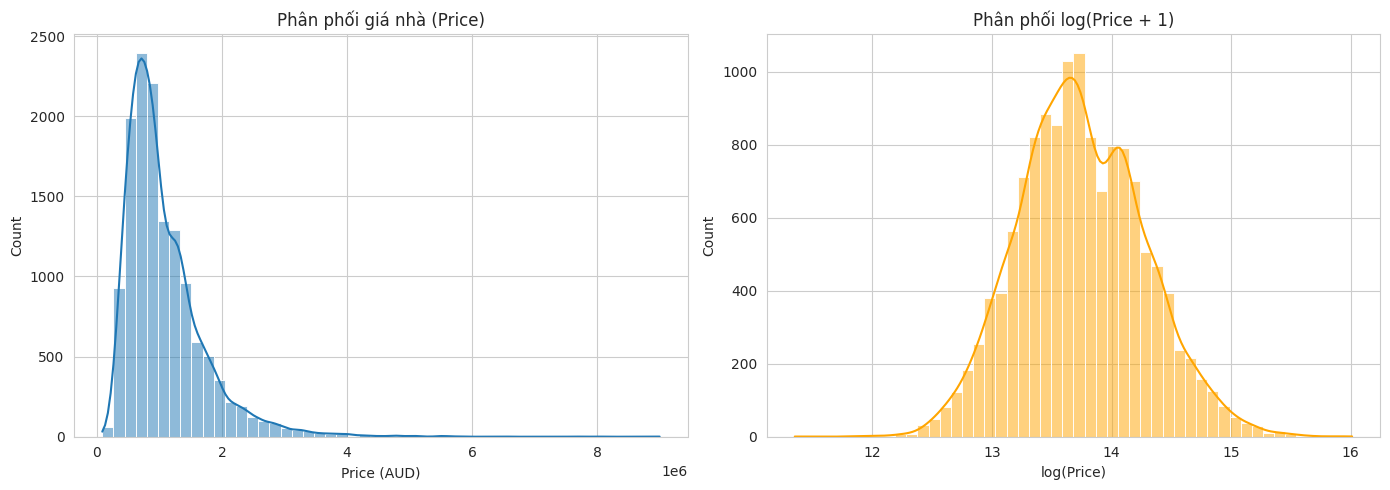

Độ lệch (skewness) của Price: 2.24


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Price'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Phân phối giá nhà (Price)')
axes[0].set_xlabel('Price (AUD)')

sns.histplot(np.log1p(df['Price']), bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Phân phối log(Price + 1)')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

print("Độ lệch (skewness) của Price:", df['Price'].skew().round(2))


**Nhận xét:** Giá nhà bị lệch phải (right-skewed) khá mạnh — phần lớn nhà có giá trong khoảng phổ biến, nhưng có một số nhà giá rất cao (outliers).

### 3.5. Ma trận tương quan giữa các biến số

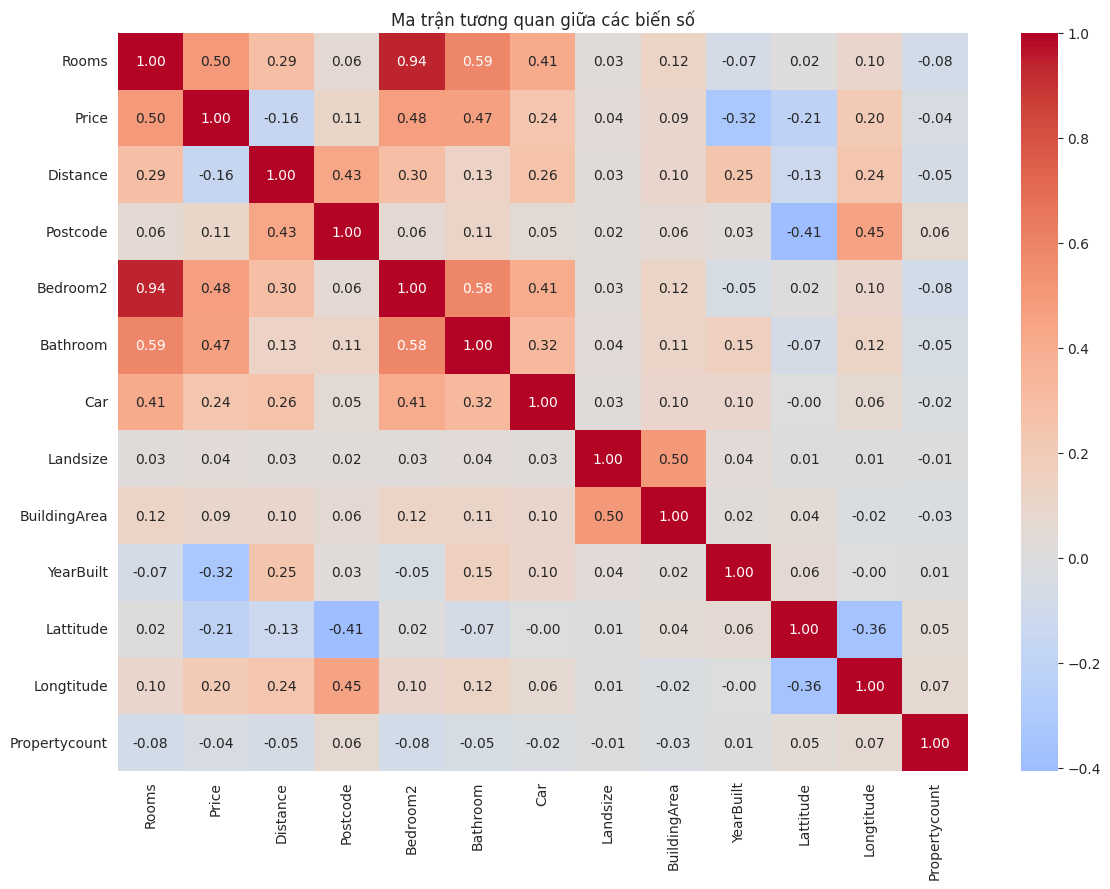

In [ ]:
numeric_cols_check = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols_check].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Ma trận tương quan giữa các biến số')
plt.tight_layout()
plt.show()


### 3.6. Quan hệ giữa một số biến categorical và Price

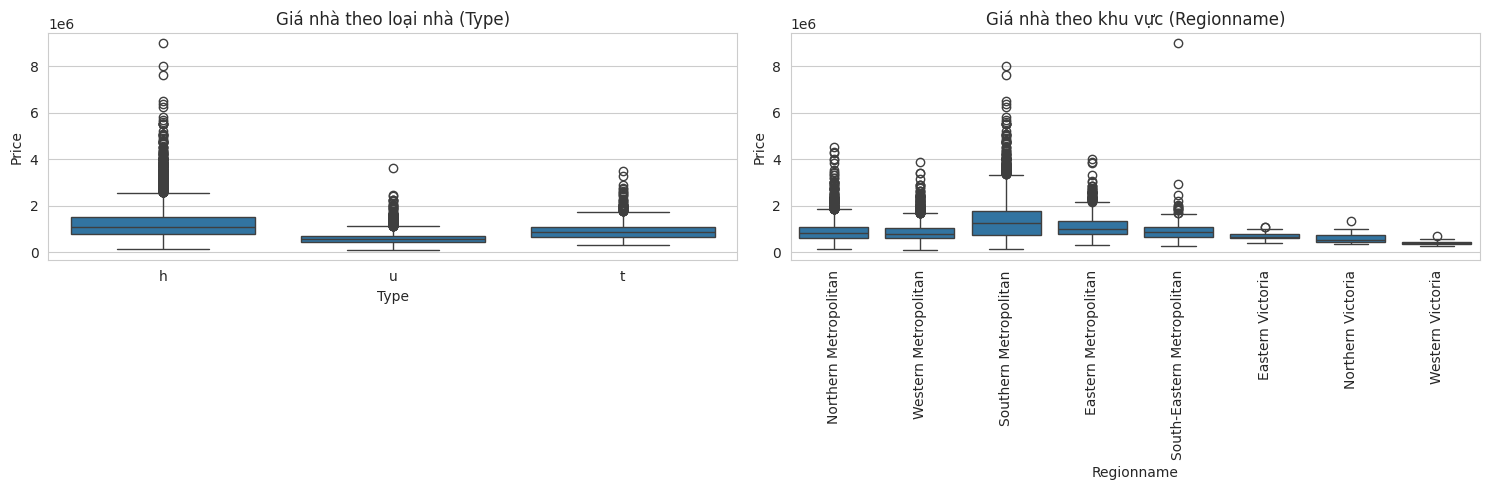

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='Type', y='Price', ax=axes[0])
axes[0].set_title('Giá nhà theo loại nhà (Type)')

sns.boxplot(data=df, x='Regionname', y='Price', ax=axes[1])
axes[1].set_title('Giá nhà theo khu vực (Regionname)')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


## 4. Tiền xử lý dữ liệu

### 4.1. Loại bỏ dòng thiếu giá trị mục tiêu (Price)


In [ ]:
df = df.dropna(subset=['Price']).reset_index(drop=True)
print("Kích thước dữ liệu sau khi loại bỏ Price bị thiếu:", df.shape)

Kích thước dữ liệu sau khi loại bỏ Price bị thiếu: (13580, 21)


### 4.2. Chọn đặc trưng (features) sử dụng

Ta loại bỏ các cột không phù hợp để đưa vào mô hình:
- `Address`: định danh duy nhất cho từng căn nhà (gần như mỗi giá trị chỉ xuất hiện 1 lần) → không có giá trị dự đoán, dễ gây overfitting.
- `Suburb`, `SellerG`: có **cardinality rất cao** (rất nhiều giá trị khác nhau), nếu one-hot encode sẽ tạo ra quá nhiều cột → làm mô hình phức tạp không cần thiết cho bài tập này.
- `Date`: là dạng ngày tháng dạng chuỗi, ta trích xuất `Sale_Year` và `Sale_Month` từ đó rồi bỏ cột gốc.

Các cột còn lại được chia thành 2 nhóm:
- **Numerical:** `Rooms`, `Distance`, `Bedroom2`, `Bathroom`, `Car`, `Landsize`, `BuildingArea`, `YearBuilt`, `Lattitude`, `Longtitude`, `Propertycount`, `Sale_Year`, `Sale_Month`
- **Categorical:** `Type`, `Method`, `Regionname`, `CouncilArea`


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Sale_Year'] = df['Date'].dt.year
df['Sale_Month'] = df['Date'].dt.month

cols_to_drop = ['Address', 'Suburb', 'SellerG', 'Date', 'Postcode']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

target = 'Price'
X = df.drop(columns=[target])
y = df[target]

numerical_features = ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize',
                       'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude',
                       'Propertycount', 'Sale_Year', 'Sale_Month']
categorical_features = ['Type', 'Method', 'Regionname', 'CouncilArea']

numerical_features = [c for c in numerical_features if c in X.columns]
categorical_features = [c for c in categorical_features if c in X.columns]

X = X[numerical_features + categorical_features]

print("Số biến numerical:", len(numerical_features), "->", numerical_features)
print("Số biến categorical:", len(categorical_features), "->", categorical_features)
print("Kích thước X:", X.shape)


Số biến numerical: 13 -> ['Rooms', 'Distance', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount', 'Sale_Year', 'Sale_Month']
Số biến categorical: 4 -> ['Type', 'Method', 'Regionname', 'CouncilArea']
Kích thước X: (13580, 17)


## 5. Chia tập train/test (80/20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test :", X_test.shape)


Kích thước tập train: (10864, 17)
Kích thước tập test : (2716, 17)


## 6. Xây dựng Pipeline tiền xử lý

In [ ]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Rooms', 'Distance', 'Bedroom2', 'Bathroom',
                                  'Car', 'Landsize', 'BuildingArea',
                                  'YearBuilt', 'Lattitude', 'Longtitude',
                                  'Propertycount', 'Sale_Year', 'Sale_Month']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Missing',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Type', 'Method', 'Regionname',
                                  'CouncilArea'])])

## 7. Xây dựng và huấn luyện các mô hình hồi quy

1. **Linear Regression**
2. **Decision Tree Regressor**
3. **Random Forest Regressor**

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
}

pipelines = {}
for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"Đã huấn luyện xong: {name}")


Đã huấn luyện xong: Linear Regression
Đã huấn luyện xong: Decision Tree
Đã huấn luyện xong: Random Forest


## 8. Đánh giá mô hình trên tập test

In [ ]:
results = []

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,Random Forest,161721.725387,266738.194402,0.820879
1,Linear Regression,256147.709520,375494.873272,0.645037
2,Decision Tree,226232.664948,386588.559050,0.623753


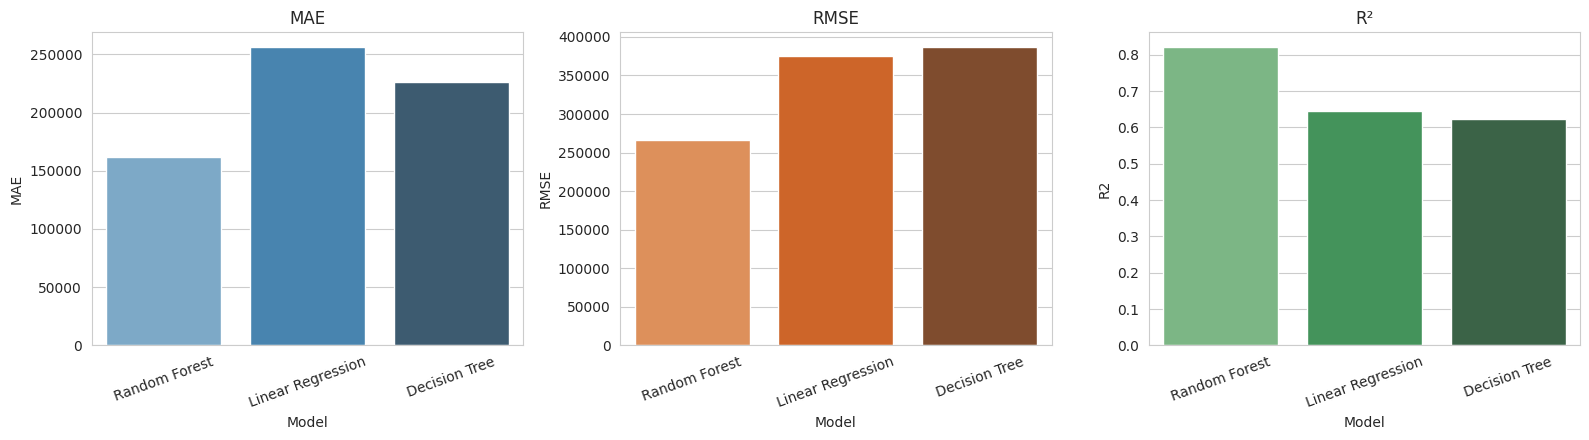

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.barplot(data=results_df, x='Model', y='MAE', hue='Model', ax=axes[0], palette='Blues_d', legend=False)
axes[0].set_title('MAE')

sns.barplot(data=results_df, x='Model', y='RMSE', hue='Model', ax=axes[1], palette='Oranges_d', legend=False)
axes[1].set_title('RMSE')

sns.barplot(data=results_df, x='Model', y='R2', hue='Model', ax=axes[2], palette='Greens_d', legend=False)
axes[2].set_title('R²')

for ax in axes:
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## 9. Phân tích thêm

### 9.1. Biểu đồ Giá trị thực tế vs. Giá trị dự đoán (mô hình tốt nhất)

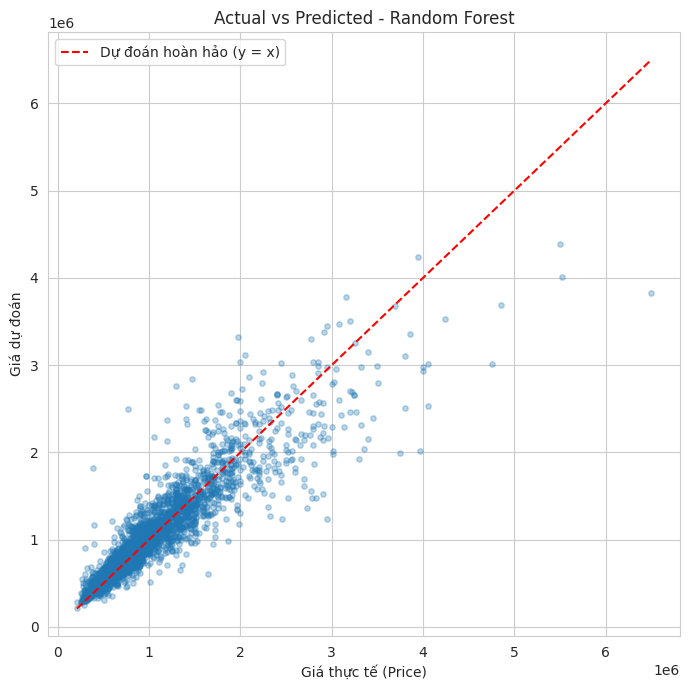

Mô hình tốt nhất: Random Forest
           Model            MAE           RMSE        R2
0  Random Forest  161721.725387  266738.194402  0.820879


In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_pipe = pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=15)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, 'r--', label='Dự đoán hoàn hảo (y = x)')
plt.xlabel('Giá thực tế (Price)')
plt.ylabel('Giá dự đoán')
plt.title(f'Actual vs Predicted - {best_model_name}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mô hình tốt nhất: {best_model_name}")
print(results_df[results_df['Model'] == best_model_name])


### 9.2. Phân tích phần dư (Residuals)

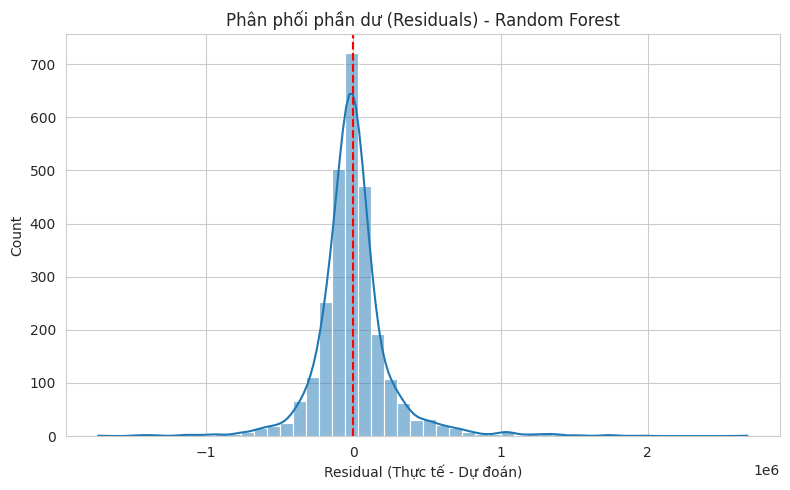

In [ ]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title(f'Phân phối phần dư (Residuals) - {best_model_name}')
plt.xlabel('Residual (Thực tế - Dự đoán)')
plt.tight_layout()
plt.show()


### 9.3. Mức độ quan trọng của các đặc trưng (Feature Importance)

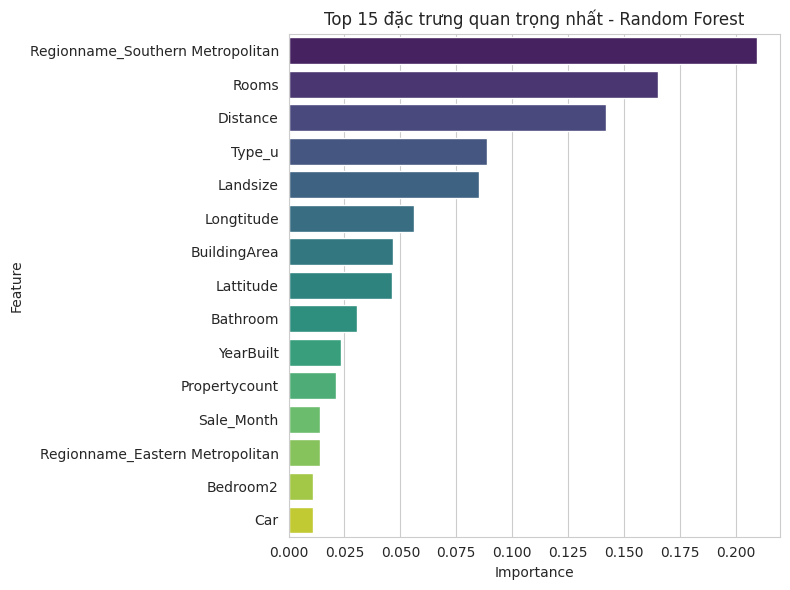

In [ ]:
if best_model_name in ['Random Forest', 'Decision Tree']:
    # Lấy tên các cột sau khi qua ColumnTransformer (bao gồm cả cột one-hot)
    ohe_feature_names = best_pipe.named_steps['preprocessor']\
        .named_transformers_['cat'].named_steps['onehot']\
        .get_feature_names_out(categorical_features)
    all_feature_names = numerical_features + list(ohe_feature_names)

    importances = best_pipe.named_steps['regressor'].feature_importances_
    feat_imp_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=feat_imp_df, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
    plt.title(f'Top 15 đặc trưng quan trọng nhất - {best_model_name}')
    plt.tight_layout()
    plt.show()

    feat_imp_df
else:
    print("Mô hình tốt nhất là Linear Regression - xem hệ số hồi quy bên dưới thay vì feature importance.")


## 10. Kết luận

- Đã xây dựng thành công pipeline dự đoán giá nhà từ dữ liệu **Melbourne Housing Snapshot**, kết hợp đầy đủ cả biến **numerical** và **categorical**.
- Dữ liệu được tiền xử lý đúng chuẩn: xử lý missing values (median cho numerical, hằng số cho categorical), chuẩn hóa (`StandardScaler`) và mã hóa (`OneHotEncoder`), tất cả được gói gọn trong `Pipeline`/`ColumnTransformer` để **tránh rò rỉ dữ liệu (data leakage)** giữa tập train và test.
- Trong 3 mô hình thử nghiệm, mô hình có chỉ số **R² cao nhất và MAE/RMSE thấp nhất**